After realizing that RF was stricly worse than estimating the mean, and that LOSO might be too strict, this code is designed to compare XGB and RF  with both LOSO and random splits. I may also eventually pull in OSM data on power infrastructure, which is a feature that I think could be useful.

In [1]:
# --- Cell 1: Imports and data loading ---

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# Load dataset WITH T50 INSTEAD OF T90
rf_v5_t50_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_rf_v5_t50.csv"

event_df = pd.read_csv(rf_v5_t50_path)

# Ensure types
event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)
event_df["event_start"] = pd.to_datetime(event_df["event_start"])

print(event_df.shape)
print(event_df.columns.tolist())
print(event_df.head())

(90, 23)
['event_id', 'storm', 'CountyFIPS', 't90', 't90_censored', 'max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'max_customers_tracked', 'county_pop', 'event_start', 'min_dist_to_storm_km', 'matched_ibtracs_storm', 'storm_max_wind_center_in_conus_mps', 'storm_max_wind_near_conus_mps', 'year', 'county_gdp_real_2017_dollars', 'county_gdp_real_2017_per_capita', 't90_new', 't90_censored_new', 't50', 't50_censored']
                            event_id          storm CountyFIPS         t90  \
0  2017212N28275_2017-07-30 21:00:00  2017212N28275      12075    1.885185   
1  2017242N16333_2017-09-09 19:00:00  2017242N16333      12037  120.406155   
2  2017242N16333_2017-09-09 20:00:00  2017242N16333      12067  186.802564   
3  2017242N16333_2017-09-09 21:00:00  2017242N16333      12013   52.651220   
4  2017242N16333_2017-09-09 22:00:00  2017242N16333      12075  170.764203   

   t90_censored   max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  \
0             0 

In [2]:
# --- Cell 2: Feature setup ---

FEATURES = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

# --- Optional: include infrastructure features once ready ---
# FEATURES += [
#     "substation_count",
#     "substation_density",
# ]

TARGET = "t50"
GROUP = "storm"

X = event_df[FEATURES].copy()
y = event_df[TARGET].copy()
groups = event_df[GROUP].copy()

print("Feature preview:")
print(X.head())

Feature preview:
    max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  county_pop  \
0  12.601287      7.421799        67.413998      1009.864246       45260   
1  27.279316     12.005697        92.750718       995.318712       12498   
2  33.241034      9.333728       153.916280       982.833530        7786   
3  25.291777     14.104932        89.230104       996.010565       13464   
4  33.169058      9.553964       145.733609       976.919507       45260   

   min_dist_to_storm_km  storm_max_wind_near_conus_mps  \
0            201.493105                       25.72220   
1            169.092475                       59.16106   
2             34.289274                       59.16106   
3            165.682470                       59.16106   
4             31.525385                       59.16106   

   county_gdp_real_2017_dollars  county_gdp_real_2017_per_capita  
0                   922164000.0                     20374.812196  
1                   337899000.0            

In [3]:
# --- Cell 3: Preprocessing and model definitions ---

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), FEATURES)
])

def get_rf():
    return RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=6,
        max_features=0.2,
        random_state=42
    )

def get_xgb():
    return XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    )

In [4]:
# --- Cell 4: Evaluation functions ---

def evaluate_random_split(model_fn, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = Pipeline([
        ("preprocess", preprocess),
        ("model", model_fn())
    ])

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return preds, y_test, {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    }


def evaluate_loso(model_fn, X, y, groups):
    logo = LeaveOneGroupOut()
    preds = np.full(len(y), np.nan)

    for train_idx, test_idx in logo.split(X, y, groups):
        model = Pipeline([
            ("preprocess", preprocess),
            ("model", model_fn())
        ])

        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds[test_idx] = model.predict(X.iloc[test_idx])

    return preds, {
        "MAE": mean_absolute_error(y, preds),
        "RMSE": np.sqrt(mean_squared_error(y, preds)),
        "R2": r2_score(y, preds)
    }


def evaluate_mean_loso(y, groups):
    logo = LeaveOneGroupOut()
    preds = np.full(len(y), np.nan)

    for train_idx, test_idx in logo.split(y, y, groups):
        preds[test_idx] = y.iloc[train_idx].mean()

    return preds, {
        "MAE": mean_absolute_error(y, preds),
        "RMSE": np.sqrt(mean_squared_error(y, preds)),
        "R2": r2_score(y, preds)
    }

def evaluate_mean_random(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # mean of training set only (no leakage)
    train_mean = y_train.mean()

    preds = np.full(len(y_test), train_mean)

    return preds, y_test, {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    }

In [5]:
# --- Cell 5: Run models ---

results = []

# Random split
rf_rand_preds, rf_rand_y, rf_rand_metrics = evaluate_random_split(get_rf, X, y)
xgb_rand_preds, xgb_rand_y, xgb_rand_metrics = evaluate_random_split(get_xgb, X, y)

# LOSO
rf_loso_preds, rf_loso_metrics = evaluate_loso(get_rf, X, y, groups)
xgb_loso_preds, xgb_loso_metrics = evaluate_loso(get_xgb, X, y, groups)

# Mean baselines
mean_loso_preds, mean_loso_metrics = evaluate_mean_loso(y, groups)
mean_rand_preds, mean_rand_y, mean_rand_metrics = evaluate_mean_random(X, y)

# Collect results (ALL go here before DataFrame creation)
results.append(("RF_random", rf_rand_metrics))
results.append(("XGB_random", xgb_rand_metrics))
results.append(("Mean_random", mean_rand_metrics))

results.append(("RF_LOSO", rf_loso_metrics))
results.append(("XGB_LOSO", xgb_loso_metrics))
results.append(("Mean_LOSO", mean_loso_metrics))

# Build DataFrame
results_df = pd.DataFrame(
    [(name, r["MAE"], r["RMSE"], r["R2"]) for name, r in results],
    columns=["Model", "MAE", "RMSE", "R2"]
)

# Optional: nicer ordering
results_df = results_df.set_index("Model").loc[
    ["RF_random", "XGB_random", "Mean_random",
     "RF_LOSO", "XGB_LOSO", "Mean_LOSO"]
].reset_index()

print(results_df)

         Model        MAE       RMSE        R2
0    RF_random  36.381375  45.068175  0.152919
1   XGB_random  24.030305  28.784512  0.654456
2  Mean_random  43.512755  51.903214 -0.123501
3      RF_LOSO  51.421105  77.158748 -0.188459
4     XGB_LOSO  71.936477  94.918161 -0.798508
5    Mean_LOSO  47.509859  74.099828 -0.096095


^ ignore that; the 35 is likely a lucky split

In [6]:
# --- Cell 5 replacement: More reliable model comparison ---
# Uses repeated shuffled K-fold CV for the "random split" setting,
# and keeps LOSO as the strict unseen-storm evaluation.

from sklearn.model_selection import RepeatedKFold, LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# -----------------------
# Generic metric helper
# -----------------------

def compute_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


# -----------------------
# Repeated random CV
# -----------------------

def evaluate_repeated_kfold(model_fn, X, y, n_splits=5, n_repeats=20, random_state=42):
    rkf = RepeatedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state
    )

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(rkf.split(X), start=1):
        model = Pipeline([
            ("preprocess", preprocess),
            ("model", model_fn())
        ])

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        metrics = compute_metrics(y_test, preds)
        metrics["fold"] = fold
        fold_results.append(metrics)

    return pd.DataFrame(fold_results)


def evaluate_mean_repeated_kfold(X, y, n_splits=5, n_repeats=20, random_state=42):
    rkf = RepeatedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state
    )

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(rkf.split(X), start=1):
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        preds = np.full(len(y_test), y_train.mean())

        metrics = compute_metrics(y_test, preds)
        metrics["fold"] = fold
        fold_results.append(metrics)

    return pd.DataFrame(fold_results)


# -----------------------
# LOSO evaluation
# -----------------------

def evaluate_loso_global(model_fn, X, y, groups):
    logo = LeaveOneGroupOut()
    preds = np.full(len(y), np.nan)

    for train_idx, test_idx in logo.split(X, y, groups):
        model = Pipeline([
            ("preprocess", preprocess),
            ("model", model_fn())
        ])

        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds[test_idx] = model.predict(X.iloc[test_idx])

    return preds, compute_metrics(y, preds)


def evaluate_mean_loso_global(y, groups):
    logo = LeaveOneGroupOut()
    preds = np.full(len(y), np.nan)

    for train_idx, test_idx in logo.split(y, y, groups):
        preds[test_idx] = y.iloc[train_idx].mean()

    return preds, compute_metrics(y, preds)


# -----------------------
# Run repeated random CV
# -----------------------

rf_random_cv = evaluate_repeated_kfold(get_rf, X, y)
xgb_random_cv = evaluate_repeated_kfold(get_xgb, X, y)
mean_random_cv = evaluate_mean_repeated_kfold(X, y)

# Optional: include MLR / linear regression if you have get_linear_regression defined
# mlr_random_cv = evaluate_repeated_kfold(get_linear_regression, X, y)


# -----------------------
# Run LOSO
# -----------------------

rf_loso_preds, rf_loso_metrics = evaluate_loso_global(get_rf, X, y, groups)
xgb_loso_preds, xgb_loso_metrics = evaluate_loso_global(get_xgb, X, y, groups)
mean_loso_preds, mean_loso_metrics = evaluate_mean_loso_global(y, groups)

# Optional: include MLR / linear regression if you have get_linear_regression defined
# mlr_loso_preds, mlr_loso_metrics = evaluate_loso_global(get_linear_regression, X, y, groups)


# -----------------------
# Summarise results
# -----------------------

def summarize_cv_results(name, df):
    return {
        "Model": name,
        "Evaluation": "Repeated 5-fold CV",
        "MAE_mean": df["MAE"].mean(),
        "MAE_sd": df["MAE"].std(),
        "RMSE_mean": df["RMSE"].mean(),
        "RMSE_sd": df["RMSE"].std(),
        "R2_mean": df["R2"].mean(),
        "R2_sd": df["R2"].std(),
    }


def summarize_loso_results(name, metrics):
    return {
        "Model": name,
        "Evaluation": "LOSO",
        "MAE_mean": metrics["MAE"],
        "MAE_sd": np.nan,
        "RMSE_mean": metrics["RMSE"],
        "RMSE_sd": np.nan,
        "R2_mean": metrics["R2"],
        "R2_sd": np.nan,
    }


summary_rows = [
    summarize_cv_results("Mean", mean_random_cv),
    summarize_cv_results("RF", rf_random_cv),
    summarize_cv_results("XGB", xgb_random_cv),

    summarize_loso_results("Mean", mean_loso_metrics),
    summarize_loso_results("RF", rf_loso_metrics),
    summarize_loso_results("XGB", xgb_loso_metrics),
]

# Optional: include MLR / linear regression
# summary_rows.insert(1, summarize_cv_results("MLR", mlr_random_cv))
# summary_rows.append(summarize_loso_results("MLR", mlr_loso_metrics))

results_df = pd.DataFrame(summary_rows)

print(results_df)

  Model          Evaluation   MAE_mean     MAE_sd  RMSE_mean    RMSE_sd  \
0  Mean  Repeated 5-fold CV  45.995141   9.699001  67.113445  25.458842   
1    RF  Repeated 5-fold CV  41.295431   9.713923  60.934705  24.838167   
2   XGB  Repeated 5-fold CV  35.636317  10.767459  54.604364  22.955936   
3  Mean                LOSO  47.509859        NaN  74.099828        NaN   
4    RF                LOSO  51.421105        NaN  77.158748        NaN   
5   XGB                LOSO  71.936477        NaN  94.918161        NaN   

    R2_mean     R2_sd  
0 -0.154038  0.264186  
1  0.057227  0.256484  
2  0.189360  0.443079  
3 -0.096095       NaN  
4 -0.188459       NaN  
5 -0.798508       NaN  


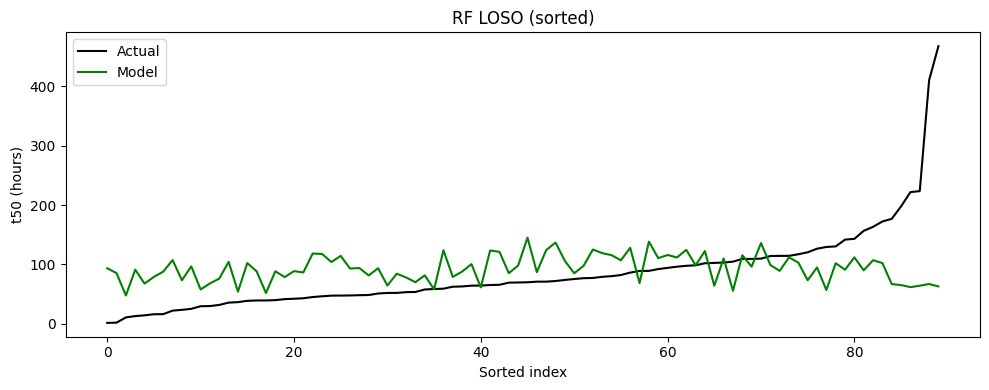

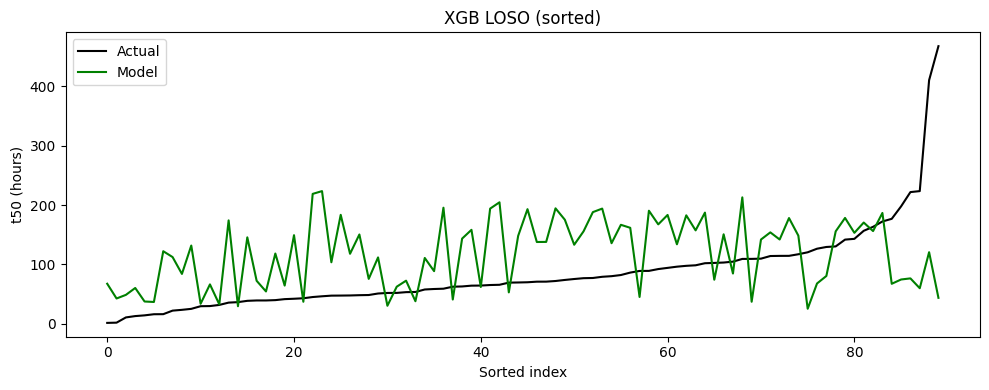

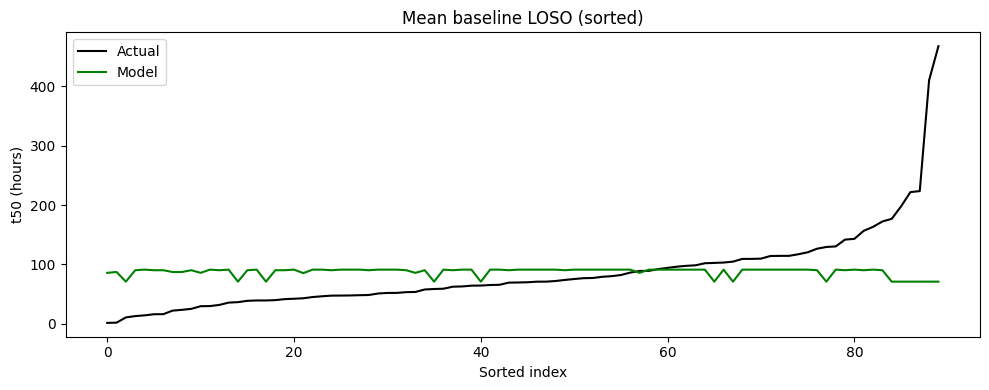

In [7]:
# --- Cell 6: Sorted prediction plots (like paper) ---

def plot_sorted(y_true, y_pred, title):
    order = np.argsort(y_true)
    y_sorted = y_true[order]
    pred_sorted = y_pred[order]

    x = np.arange(len(y_sorted))

    plt.figure(figsize=(10, 4))
    plt.plot(x, y_sorted, color="black", label="Actual")
    plt.plot(x, pred_sorted, color="green", label="Model")
    plt.xlabel("Sorted index")
    plt.ylabel("t50 (hours)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# LOSO plots (most important)
plot_sorted(y.values, rf_loso_preds, "RF LOSO (sorted)")
plot_sorted(y.values, xgb_loso_preds, "XGB LOSO (sorted)")
plot_sorted(y.values, mean_loso_preds, "Mean baseline LOSO (sorted)")

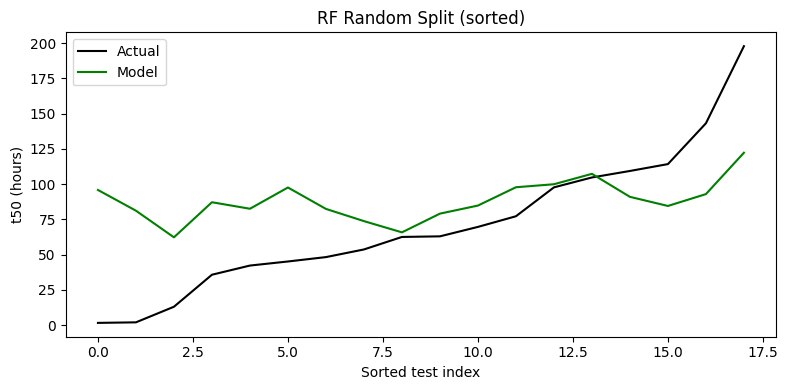

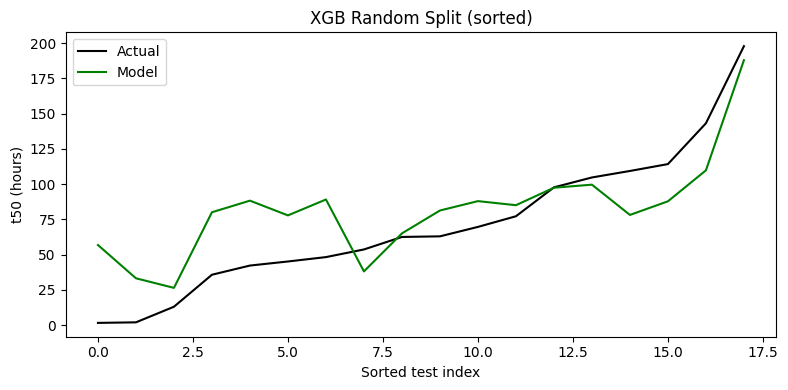

In [8]:
# --- Sorted plots for random split (test set only) ---
# (much smaller sample size, so more jagged, but still worth looking at)

def plot_sorted_random(y_true, y_pred, title):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    order = np.argsort(y_true)
    y_sorted = y_true[order]
    pred_sorted = y_pred[order]

    x = np.arange(len(y_sorted))

    plt.figure(figsize=(8, 4))
    plt.plot(x, y_sorted, color="black", label="Actual")
    plt.plot(x, pred_sorted, color="green", label="Model")
    plt.xlabel("Sorted test index")
    plt.ylabel("t50 (hours)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# RF random split
plot_sorted_random(rf_rand_y.values, rf_rand_preds, "RF Random Split (sorted)")

# XGB random split
plot_sorted_random(xgb_rand_y.values, xgb_rand_preds, "XGB Random Split (sorted)")

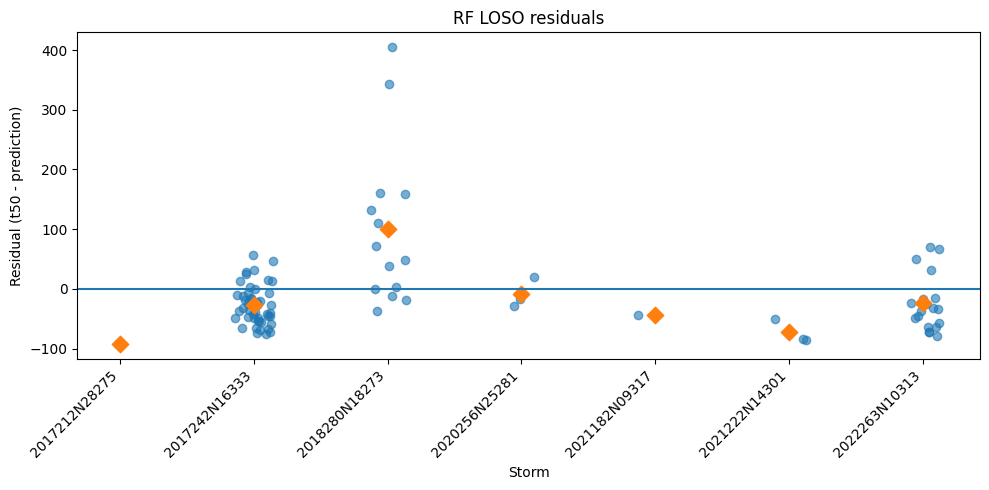

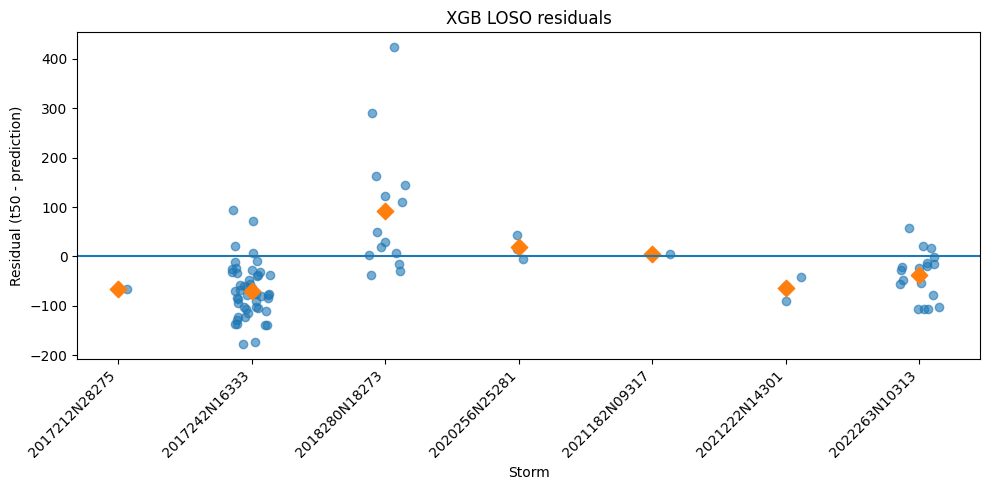

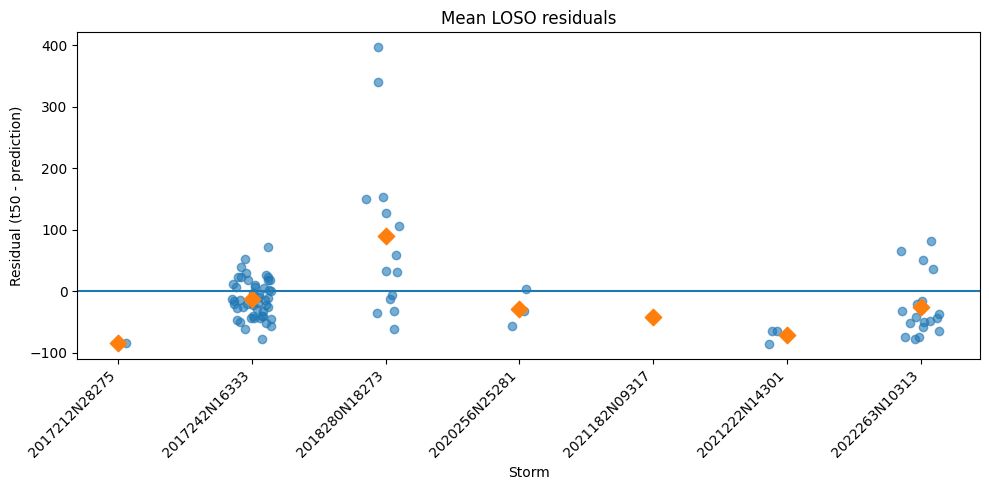

In [9]:
# --- Cell 7: Residual-by-storm plot ---

def plot_residuals_by_storm(preds, y, groups, title):
    df = pd.DataFrame({
        "storm": groups,
        "residual": y - preds
    })

    storms = sorted(df["storm"].unique())
    storm_to_x = {s: i for i, s in enumerate(storms)}

    x = df["storm"].map(storm_to_x).astype(float).values
    jitter = np.random.uniform(-0.15, 0.15, size=len(x))

    plt.figure(figsize=(10, 5))
    plt.scatter(x + jitter, df["residual"], alpha=0.6)

    means = df.groupby("storm")["residual"].mean()
    xs = np.arange(len(storms))
    plt.scatter(xs, means.values, marker="D", s=70)

    plt.axhline(0)
    plt.xticks(xs, storms, rotation=45, ha="right")
    plt.xlabel("Storm")
    plt.ylabel("Residual (t50 - prediction)")
    plt.title(title)

    plt.tight_layout()
    plt.show()


plot_residuals_by_storm(rf_loso_preds, y, groups, "RF LOSO residuals")
plot_residuals_by_storm(xgb_loso_preds, y, groups, "XGB LOSO residuals")
plot_residuals_by_storm(mean_loso_preds, y, groups, "Mean LOSO residuals")

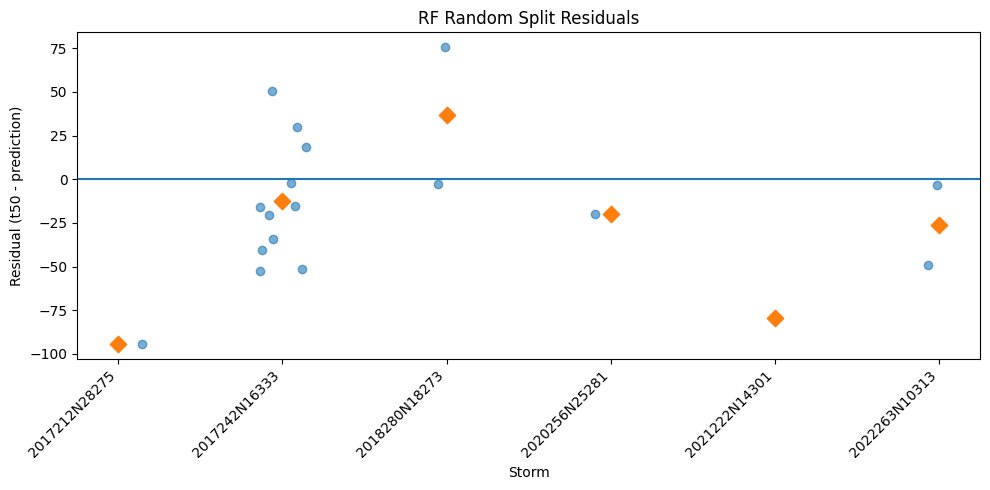

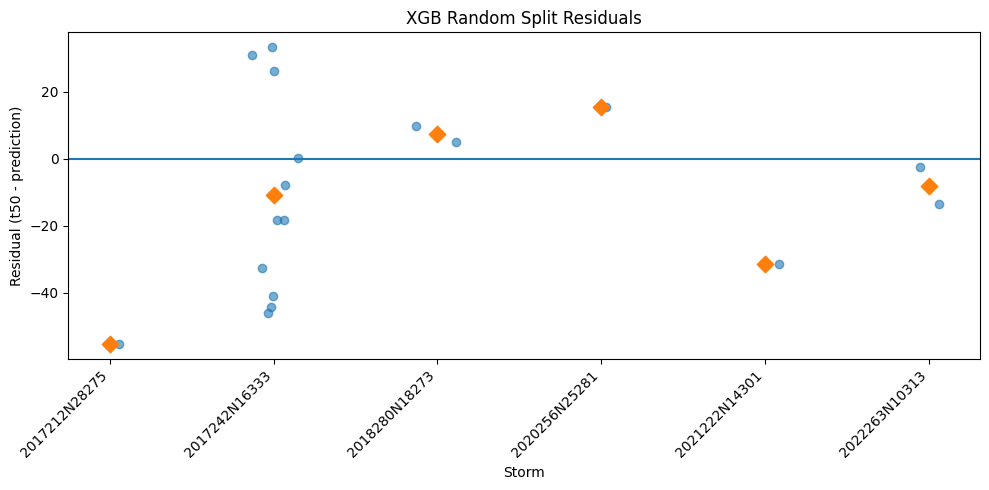

In [10]:
# --- Residual plots for random split (test set only) ---

def plot_residuals_by_storm_random(preds, y_true, storms, title):
    df = pd.DataFrame({
        "storm": storms,
        "residual": y_true - preds
    })

    storms_unique = sorted(df["storm"].unique())
    storm_to_x = {s: i for i, s in enumerate(storms_unique)}

    x = df["storm"].map(storm_to_x).astype(float).values
    jitter = np.random.uniform(-0.15, 0.15, size=len(x))

    plt.figure(figsize=(10, 5))
    plt.scatter(x + jitter, df["residual"], alpha=0.6)

    # Mean residual per storm
    means = df.groupby("storm")["residual"].mean()
    xs = np.arange(len(storms_unique))
    plt.scatter(xs, means.values, marker="D", s=70)

    plt.axhline(0)
    plt.xticks(xs, storms_unique, rotation=45, ha="right")
    plt.xlabel("Storm")
    plt.ylabel("Residual (t50 - prediction)")
    plt.title(title)

    plt.tight_layout()
    plt.show()


# --- RF random split residuals ---
plot_residuals_by_storm_random(
    rf_rand_preds,
    rf_rand_y.values,
    groups.loc[rf_rand_y.index],
    "RF Random Split Residuals"
)

# --- XGB random split residuals ---
plot_residuals_by_storm_random(
    xgb_rand_preds,
    xgb_rand_y.values,
    groups.loc[xgb_rand_y.index],
    "XGB Random Split Residuals"
)

**Now let's try tuning XGB just for fun. Both LOSO and random splits. Still no OSM.**

In [11]:
from itertools import product

param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
}

param_list = list(product(
    param_grid["n_estimators"],
    param_grid["max_depth"],
    param_grid["learning_rate"],
    param_grid["subsample"],
    param_grid["colsample_bytree"]
))

print("Total configs:", len(param_list))

Total configs: 108


In [12]:
from sklearn.model_selection import KFold

def tune_xgb_random(X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    results = []

    for params in param_list:
        n_estimators, max_depth, lr, subsample, colsample = params

        fold_maes = []

        for train_idx, test_idx in kf.split(X):
            model = Pipeline([
                ("preprocess", preprocess),
                ("model", XGBRegressor(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    learning_rate=lr,
                    subsample=subsample,
                    colsample_bytree=colsample,
                    random_state=42,
                    objective="reg:squarederror"
                ))
            ])

            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            preds = model.predict(X.iloc[test_idx])

            fold_maes.append(mean_absolute_error(y.iloc[test_idx], preds))

        results.append({
            "params": params,
            "mae": np.mean(fold_maes)
        })

    results_df = pd.DataFrame(results).sort_values("mae")

    return results_df

In [13]:
xgb_random_results = tune_xgb_random(X, y)
print(xgb_random_results.head())

                       params        mae
67   (200, 4, 0.05, 0.9, 0.9)  30.677225
103  (400, 4, 0.05, 0.9, 0.9)  30.691897
99   (400, 4, 0.03, 0.9, 0.9)  30.893608
63   (200, 4, 0.03, 0.9, 0.9)  30.961017
98   (400, 4, 0.03, 0.9, 0.7)  31.119433


^ for random splits, tuned XGB results

In [14]:
def tune_xgb_loso(X, y, groups):
    logo = LeaveOneGroupOut()

    results = []

    for params in param_list:
        n_estimators, max_depth, lr, subsample, colsample = params

        preds = np.full(len(y), np.nan)

        for train_idx, test_idx in logo.split(X, y, groups):
            model = Pipeline([
                ("preprocess", preprocess),
                ("model", XGBRegressor(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    learning_rate=lr,
                    subsample=subsample,
                    colsample_bytree=colsample,
                    random_state=42,
                    objective="reg:squarederror"
                ))
            ])

            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            preds[test_idx] = model.predict(X.iloc[test_idx])

        mae = mean_absolute_error(y, preds)

        results.append({
            "params": params,
            "mae": mae
        })

    results_df = pd.DataFrame(results).sort_values("mae")

    return results_df

In [15]:
xgb_loso_results = tune_xgb_loso(X, y, groups)
print(xgb_loso_results.head())

                       params        mae
26   (100, 4, 0.03, 0.9, 0.7)  62.727454
30   (100, 4, 0.05, 0.9, 0.7)  63.546971
34    (100, 4, 0.1, 0.9, 0.7)  64.455981
70    (200, 4, 0.1, 0.9, 0.7)  64.488583
106   (400, 4, 0.1, 0.9, 0.7)  64.494378


In [16]:
# Best from random tuning
best_random_params = xgb_random_results.iloc[0]["params"]

# Best from LOSO tuning (if run)
best_loso_params = xgb_loso_results.iloc[0]["params"]

print("Best random:", best_random_params)
print("Best LOSO:", best_loso_params)

Best random: (200, 4, 0.05, 0.9, 0.9)
Best LOSO: (100, 4, 0.03, 0.9, 0.7)


In [17]:
def get_xgb_best(params):
    n_estimators, max_depth, lr, subsample, colsample = params

    return XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=lr,
        subsample=subsample,
        colsample_bytree=colsample,
        random_state=42,
        objective="reg:squarederror"
    )

In [18]:
xgb_loso_preds, xgb_loso_metrics = evaluate_loso(
    lambda: get_xgb_best(best_random_params),
    X, y, groups
)

print("Tuned XGB LOSO:", xgb_loso_metrics)

Tuned XGB LOSO: {'MAE': 66.31229264226307, 'RMSE': np.float64(90.52655699624931), 'R2': -0.6359337345876019}


Trying PDPs:

In [19]:
def build_xgb_from_params(params):
    n_estimators, max_depth, lr, subsample, colsample = params

    return XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=lr,
        subsample=subsample,
        colsample_bytree=colsample,
        random_state=42,
        objective="reg:squarederror"
    )

In [20]:
# Replace these with your actual best params
best_random_params = (400, 2, 0.05, 0.9, 0.9)
best_loso_params   = (100, 4, 0.03, 0.9, 0.7)

model_xgb_random_full = Pipeline([
    ("preprocess", preprocess),
    ("model", build_xgb_from_params(best_random_params))
])

model_xgb_loso_full = Pipeline([
    ("preprocess", preprocess),
    ("model", build_xgb_from_params(best_loso_params))
])

model_xgb_random_full.fit(X, y)
model_xgb_loso_full.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

In [21]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

def plot_pdp(model, X, features, title):
    fig, ax = plt.subplots(3, 3, figsize=(12, 10))

    PartialDependenceDisplay.from_estimator(
        model,
        X.astype(float),   # avoid dtype issues
        features=features,
        grid_resolution=50,
        ax=ax
    )

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

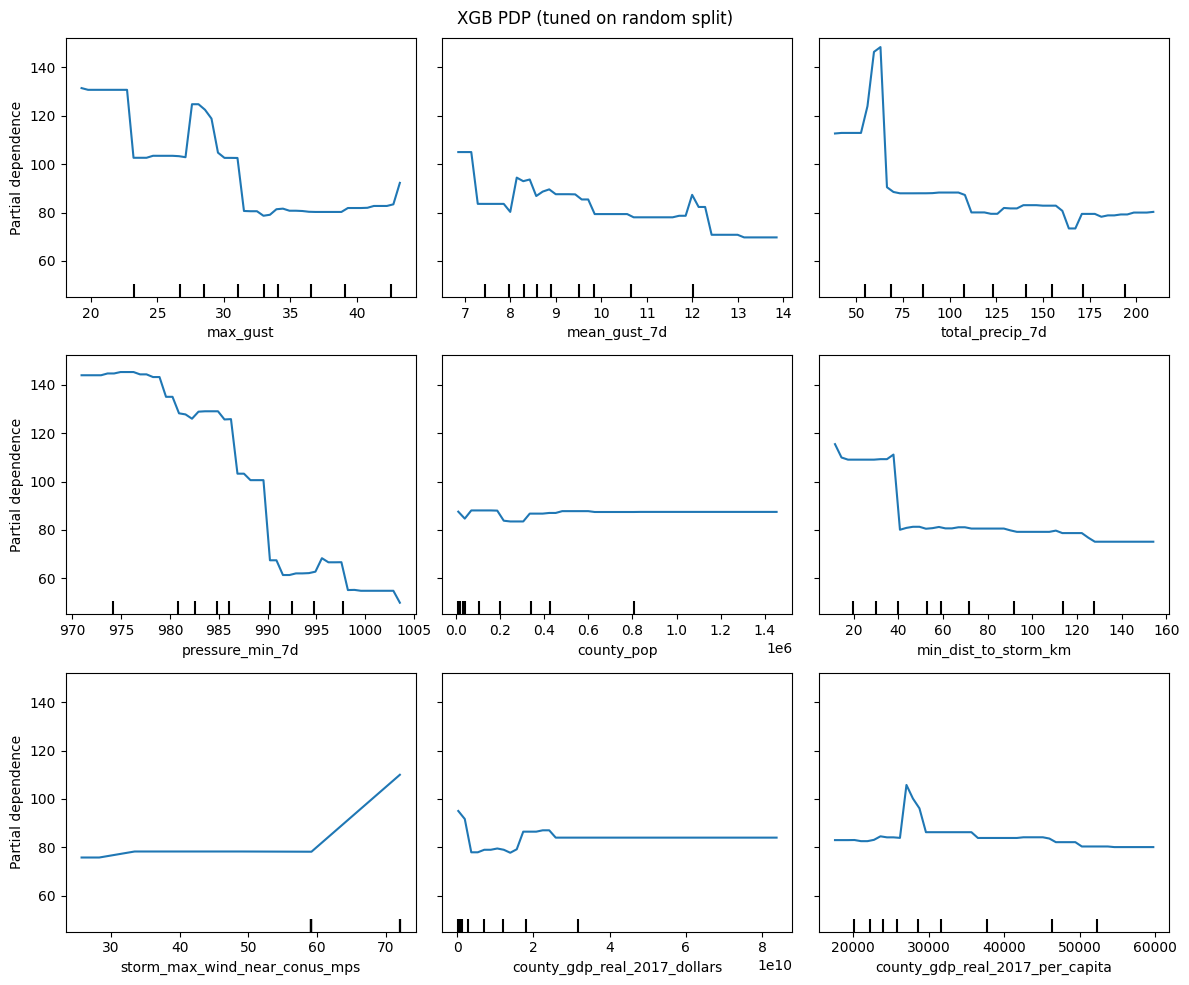

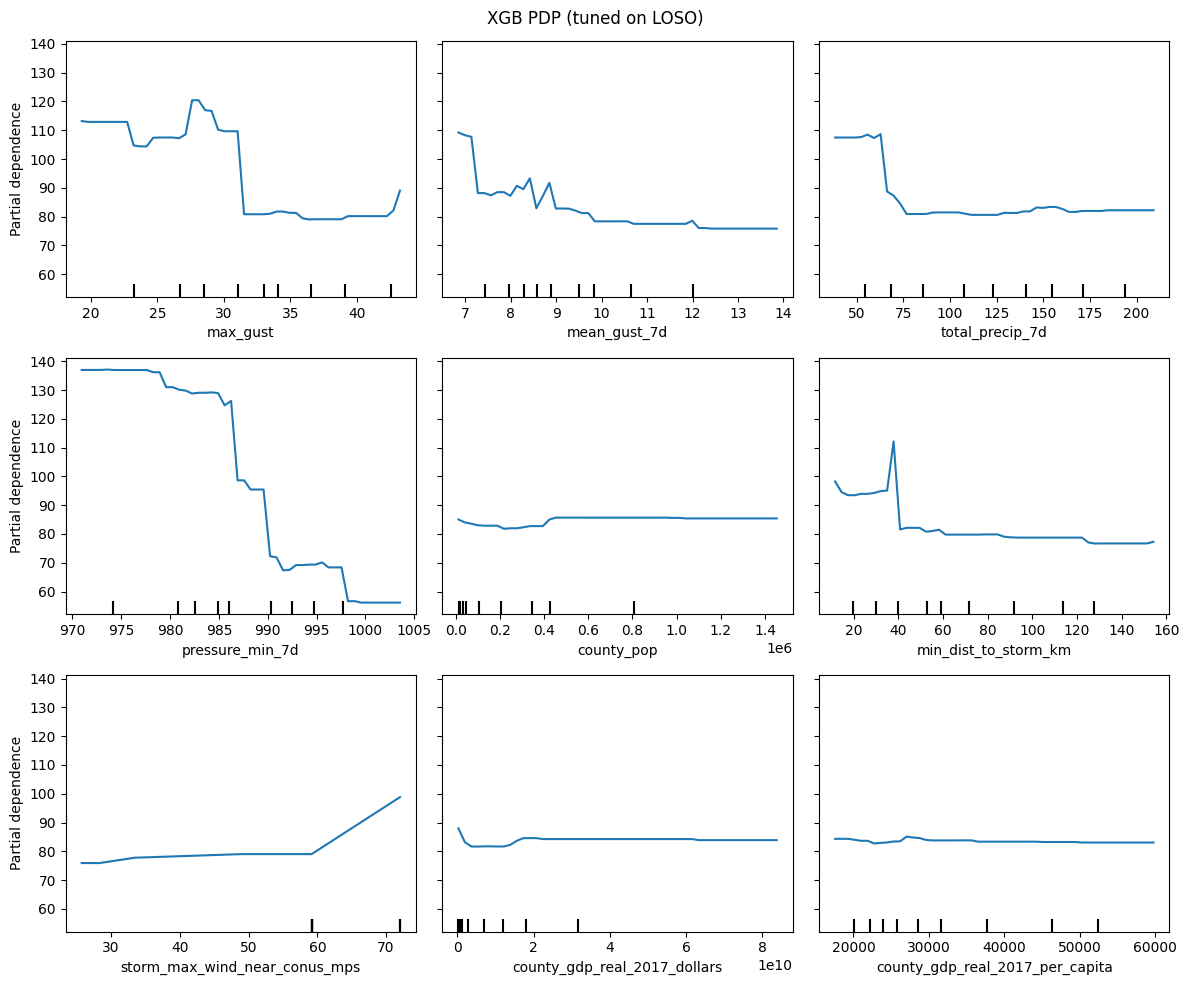

In [22]:
plot_pdp(
    model_xgb_random_full,
    X,
    FEATURES,
    "XGB PDP (tuned on random split)"
)

plot_pdp(
    model_xgb_loso_full,
    X,
    FEATURES,
    "XGB PDP (tuned on LOSO)"
)

^ that's mostly useless.

Let's try looking at just predicted vs actual:

In [23]:
def plot_scatter_by_storm(preds, y, groups, title):
    plt.figure(figsize=(7, 6))

    storms = groups.unique()

    for storm in storms:
        mask = groups == storm

        plt.scatter(
            y[mask],
            preds[mask],
            label=storm,
            alpha=0.8
        )

    # 45-degree line
    m = max(np.nanmax(y), np.nanmax(preds))
    plt.plot([0, m], [0, m], "--")

    plt.xlabel("Actual t50")
    plt.ylabel("Predicted t50")
    plt.title(title)

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

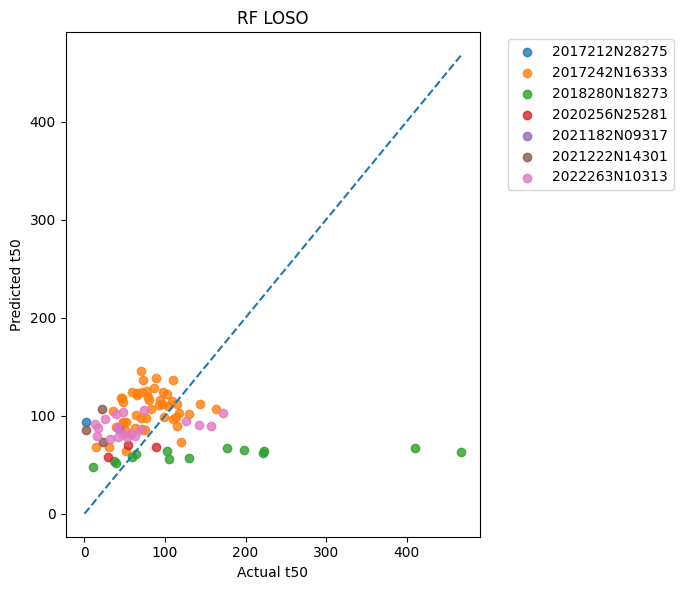

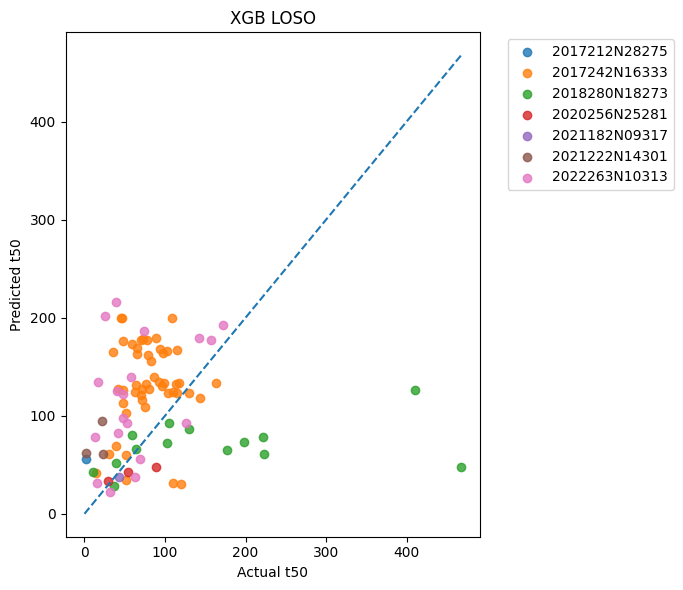

In [24]:
plot_scatter_by_storm(rf_loso_preds, y.values, groups, "RF LOSO")

plot_scatter_by_storm(xgb_loso_preds, y.values, groups, "XGB LOSO")

# plot_scatter_by_storm(mean_loso_preds, y.values, groups, "Mean LOSO")

^ XGB more scattered which is interesting. still mostly useless though.

Yu recommends:
- Add a MLR (multiple linear regression) to compare. 
- For the xgboost and mlr, compare the variable importance.

In [25]:
# --- Cell: Add MLR / ordinary least squares linear regression ---

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# For evaluation, use the same imputation-only preprocessing as RF/XGB.
# This keeps the prediction task consistent.
def get_linear_regression():
    return LinearRegression()

In [26]:
# --- Cell: Evaluate MLR alongside existing models ---

# Repeated random CV
mlr_random_cv = evaluate_repeated_kfold(get_linear_regression, X, y)

# LOSO
mlr_loso_preds, mlr_loso_metrics = evaluate_loso_global(
    get_linear_regression, X, y, groups
)

# Add MLR rows to existing results table
mlr_rows = [
    summarize_cv_results("MLR", mlr_random_cv),
    summarize_loso_results("MLR", mlr_loso_metrics),
]

results_with_mlr_df = pd.concat(
    [results_df, pd.DataFrame(mlr_rows)],
    ignore_index=True
)

# Optional ordering
results_with_mlr_df["Model"] = pd.Categorical(
    results_with_mlr_df["Model"],
    categories=["Mean", "MLR", "RF", "XGB"],
    ordered=True
)

results_with_mlr_df["Evaluation"] = pd.Categorical(
    results_with_mlr_df["Evaluation"],
    categories=["Repeated 5-fold CV", "LOSO"],
    ordered=True
)

results_with_mlr_df = results_with_mlr_df.sort_values(
    ["Evaluation", "Model"]
).reset_index(drop=True)

print(results_with_mlr_df)

  Model          Evaluation    MAE_mean     MAE_sd   RMSE_mean    RMSE_sd  \
0  Mean  Repeated 5-fold CV   45.995141   9.699001   67.113445  25.458842   
1   MLR  Repeated 5-fold CV   45.126774   8.861349   62.976121  20.230504   
2    RF  Repeated 5-fold CV   41.295431   9.713923   60.934705  24.838167   
3   XGB  Repeated 5-fold CV   35.636317  10.767459   54.604364  22.955936   
4  Mean                LOSO   47.509859        NaN   74.099828        NaN   
5   MLR                LOSO  110.922812        NaN  140.498223        NaN   
6    RF                LOSO   51.421105        NaN   77.158748        NaN   
7   XGB                LOSO   71.936477        NaN   94.918161        NaN   

    R2_mean     R2_sd  
0 -0.154038  0.264186  
1 -0.173672  0.696554  
2  0.057227  0.256484  
3  0.189360  0.443079  
4 -0.096095       NaN  
5 -2.940537       NaN  
6 -0.188459       NaN  
7 -0.798508       NaN  


^ MLR slightly better than the Mean for random splits, but way way worse for LOSO. 

In [27]:
# --- Cell: Fit full-data XGB and MLR models for variable importance ---
# These are for interpretation only, not performance evaluation.

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# XGB: use the same current get_xgb() model
xgb_full = Pipeline([
    ("preprocess", preprocess),
    ("model", get_xgb())
])

xgb_full.fit(X, y)

xgb_importance = pd.DataFrame({
    "feature": FEATURES,
    "xgb_importance": xgb_full.named_steps["model"].feature_importances_
}).sort_values("xgb_importance", ascending=False)

print("XGBoost feature importance:")
print(xgb_importance)

XGBoost feature importance:
                           feature  xgb_importance
6    storm_max_wind_near_conus_mps        0.420328
2                  total_precip_7d        0.141713
3                  pressure_min_7d        0.138615
5             min_dist_to_storm_km        0.094435
0                         max_gust        0.089437
1                     mean_gust_7d        0.067275
7     county_gdp_real_2017_dollars        0.020892
4                       county_pop        0.016736
8  county_gdp_real_2017_per_capita        0.010568


^ storm-level severity most important.

In [28]:
# --- Cell: MLR standardized coefficients ---
# Standardization is important because otherwise variables with large units
# such as GDP/population are not comparable to wind/pressure variables.

mlr_preprocess_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), FEATURES)
])

mlr_full_scaled = Pipeline([
    ("preprocess", mlr_preprocess_scaled),
    ("model", LinearRegression())
])

mlr_full_scaled.fit(X, y)

mlr_importance = pd.DataFrame({
    "feature": FEATURES,
    "mlr_coef_standardized": mlr_full_scaled.named_steps["model"].coef_,
})

mlr_importance["mlr_abs_coef"] = mlr_importance["mlr_coef_standardized"].abs()

mlr_importance = mlr_importance.sort_values(
    "mlr_abs_coef",
    ascending=False
)

print("MLR standardized coefficients:")
print(mlr_importance)

MLR standardized coefficients:
                           feature  mlr_coef_standardized  mlr_abs_coef
3                  pressure_min_7d             -28.024793     28.024793
7     county_gdp_real_2017_dollars              23.153766     23.153766
4                       county_pop             -19.025706     19.025706
6    storm_max_wind_near_conus_mps              18.970071     18.970071
0                         max_gust             -18.061499     18.061499
1                     mean_gust_7d             -17.177249     17.177249
5             min_dist_to_storm_km              -8.164686      8.164686
8  county_gdp_real_2017_per_capita              -6.677455      6.677455
2                  total_precip_7d              -3.084319      3.084319


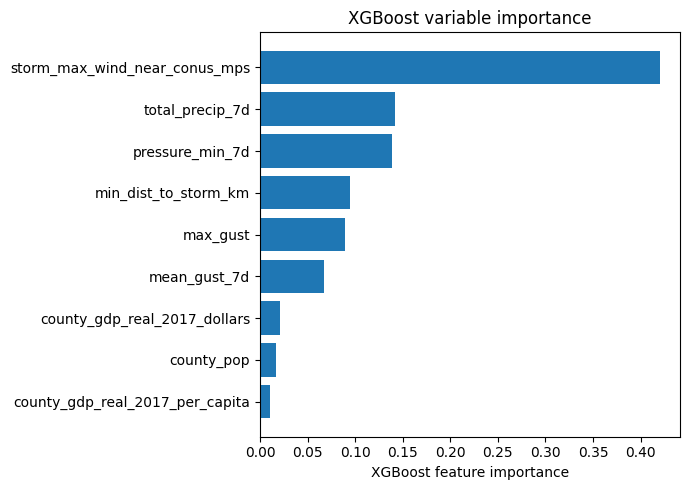

In [29]:
# --- Cell: Plot XGB feature importance ---

plt.figure(figsize=(7, 5))
plt.barh(
    xgb_importance["feature"],
    xgb_importance["xgb_importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("XGBoost feature importance")
plt.title("XGBoost variable importance")
plt.tight_layout()
plt.show()

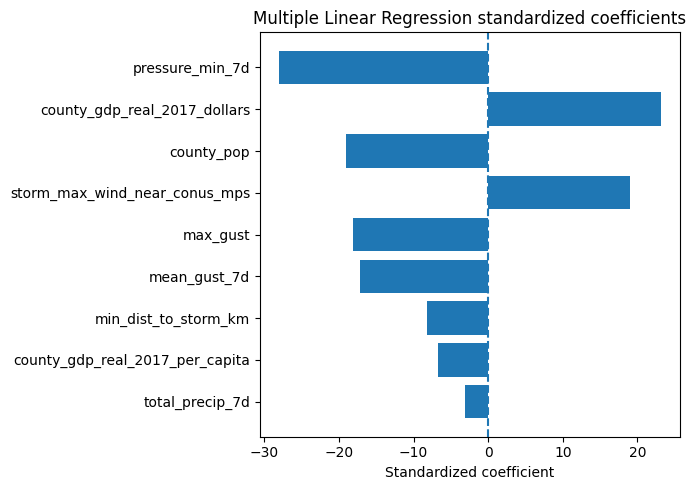

In [30]:
# --- Cell: Plot MLR standardized coefficients ---

plt.figure(figsize=(7, 5))
plt.barh(
    mlr_importance["feature"],
    mlr_importance["mlr_coef_standardized"]
)
plt.axvline(0, linestyle="--")
plt.gca().invert_yaxis()
plt.xlabel("Standardized coefficient")
plt.title("Multiple Linear Regression standardized coefficients")
plt.tight_layout()
plt.show()

Interesting that precip is more important for t50.
Variable importance is computed from a model fit on the full dataset for interpretability, not from the cross-validation procedure.